In [1]:
from collections import defaultdict
from pathlib import Path
from typing import Literal

import numpy as np
import pandas as pd
import scipy.stats as stats
import torch
import torch.nn as nn

In [2]:
folder = Path('./output/reconstr_grid1b2')
dev = pd.read_csv(folder / 'dev.csv')
dev

,trial,config,epoch,stage,metric,value
0,0,embeddim32_hiddendims0,0,train,loss,1.121293
1,0,embeddim32_hiddendims0,0,train,mse,0.903778
2,0,embeddim32_hiddendims0,0,train,rmse,0.950673
3,0,embeddim32_hiddendims0,0,train,mae,0.667302
4,0,embeddim32_hiddendims0,0,train,r2,0.762012
...,...,...,...,...,...,...
1379995,22,embeddim256_hiddendims4,299,val,loss,0.137523
1379996,22,embeddim256_hiddendims4,299,val,mse,0.600989
1379997,22,embeddim256_hiddendims4,299,val,rmse,0.775235
1379998,22,embeddim256_hiddendims4,299,val,mae,0.507749


In [3]:
def df_dataloader(
    df: pd.DataFrame, 
    stage: str = 'val',
    agg: Literal['mean', 'last'] = 'mean',

    # default col names
    trial_col: str = 'trial',
    config_col: str = 'config',
    epoch_col: str = 'epoch',
    stage_col: str = 'stage',
    metric_col: str = 'metric',
    value_col: str = 'value'

):
    cols = df.columns.drop(stage_col)

    # filter for stage
    d = df.loc[df[stage_col].eq(stage), cols].copy()

    # handle duplicates
    if agg == 'mean':
        d = d.groupby(cols.drop(value_col).tolist(), as_index=False)[value_col].mean()
    elif agg == 'last':
        d = d.sort_values(
            [trial_col, config_col, epoch_col]
        ).groupby(
            cols.drop(value_col).tolist(),
            as_index=False
        ).last()

    # pivot
    d = d.pivot_table(
        index=[trial_col, config_col, epoch_col],
        columns=metric_col,
        values=value_col
    ).sort_index()

    # iterate
    for (trial, config, epoch), row in d.iterrows():
        yield trial, config, epoch, row.dropna().to_dict()

In [29]:
class ExpMovingAverage():
    def __init__(self, alpha: float = 0.9, warmup: int = 0, eps: float = 1e-8) -> None:
        self.target_alpha = float(alpha)
        self.warmup = int(warmup)
        self.eps = float(eps)

        # trackers
        self.epoch = 0
        self.mean: float|None = None
        self.var: float|None = None

    @property
    def alpha(self) -> float:
        if self.warmup <= 0:
            return self.target_alpha
        if self.epoch < self.warmup:
            return self.target_alpha * (self.epoch + 1) / self.warmup
        return self.target_alpha
    
    @property
    def n_eff(self) -> float:
        return (1 + self.alpha) / max(1 - self.alpha, self.eps)
    
    def moe(self, z:float=1.96) -> float|None:
        if self.var is None:
            return None
        return z * np.sqrt(self.var / self.n_eff)
    
    def update(self, x:float|torch.Tensor) -> None:
        # convert to float
        if torch.is_tensor(x):
            x = x.detach().item()
        x = float(x)

        # initialize ema if None
        if self.mean is None:
            self.mean = x
            self.var = 0.0

        # update ema
        else:
            alpha = self.alpha
            mean_prev = self.mean

            self.mean = alpha * self.mean + (1 - alpha) * x
            self.var = alpha * self.var + (1 - alpha) * (x - self.mean) * (x - mean_prev)
            self.var = max(self.var, 0.0)  # ensure non-negative variance

        self.epoch += 1
        return self.mean, self.var
    

In [54]:
class EarlyStopping():
    def __init__(
        self,
        warmup: int = 50,
        patience: int = 50,
        mode: Literal['min', 'max'] = 'min',                                   
        confidence: float = 0.95,
        decay: float = 0.95,
    ):
        self.warmup = int(warmup)
        self.patience = int(patience)
        self.mode = mode

        # stats
        self.ema = ExpMovingAverage(alpha=float(decay), warmup=self.warmup)
        self.z = stats.norm.ppf(0.5 + float(confidence) / 2.0)

        # tracking variables
        self.best_epoch: int|None = None
        self.best_value: float|None = None
        self.criteria: float|None = None
        self.counter: int = 0
        self.should_stop: bool = False

        # model
        self.best_state: dict[str, torch.Tensor]|None = None
    
    def _update_criteria(self) -> float|None:
        # recomputes criteria: best val +- moe (ci)
        moe = self.ema.moe(self.z)
        moe = 0.0 if moe is None else float(moe)

        if self.mode == 'min':
            return self.best_value - moe
        else:
            return self.best_value + moe

    def _better(self, current:float, target:float) -> bool:
        return current < target if self.mode == 'min' else current > target

    def update(self, x:float|torch.Tensor, epoch:int) -> None:
        # convert to float
        if torch.is_tensor(x):
            x = x.detach().item()
        x = float(x)

        # update
        self.ema.update(x)

        # initialize
        if self.best_value is None or self.criteria is None:
            self.best_value = x # update best value
            self.best_epoch = epoch # update best epoch
            self.criteria = self._update_criteria() # update criteria
            self.counter = 0 # reset counter
            return

        # update best value, if better
        if self._better(x, self.best_value):
            self.best_value = x
            self.best_epoch = epoch

        # update criteria, if improved
        if self._better(x, self.criteria):
            self.criteria = self._update_criteria()
            self.counter = 0 # reset counter

        # apply patience after warmup
        elif epoch >= self.warmup:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True

    def update_and_save(self, x:dict|float|torch.Tensor, epoch:int, model:nn.Module, metric:str|None = None) -> None:
        # extract metric if dict
        if isinstance(x, dict):
            if metric is None:
                raise ValueError("metric must be provided when x is a dict")
            if metric not in x:
                raise KeyError(f"metric={metric!r} not found in keys={list(x.keys())}")
            x = x[metric]

        # update, best epoch etc.
        self.update(x, epoch)

        # if best epoch, save model state
        if self.best_epoch == epoch:
            self.best_state = {
                k: v.detach().cpu().clone() 
                for k, v in model.state_dict().items()
            }


---

In [55]:
import matplotlib.pyplot as plt

In [56]:
def plot_ema_var(df, trial, config):
    sub = df[(df["trial"] == trial) & (df["config"] == config)]
    sub = sub.sort_values("epoch")

    plt.figure()
    plt.plot(sub["epoch"], -sub["ema_diff"], label="EMA Mean Diff (alpha=0.95)")
    plt.plot(sub["epoch"], sub["ema_var"], label="EMA Variance (alpha=0.95)")
    plt.plot(sub["epoch"], sub["ema_std"], label="EMA Std Dev (alpha=0.95)")
    plt.plot(sub["epoch"], sub["ema_se"], label="EMA Std Error (alpha=0.95)")
    plt.plot(sub["epoch"], sub["ema_moe"], label="EMA Margin of Error (alpha=0.95)")
    plt.xlabel("Epoch")
    


    plt.ylabel("EMA Variance")
    plt.title(f"Trial {trial}, Config {config}")
    plt.legend()
    plt.grid(True)
    plt.ylim(None, 0.005)  # Set lower limit to 0, upper limit auto
    plt.show()

In [57]:
loader = df_dataloader(dev, stage='val', agg='last')
ema_state = defaultdict(lambda: ExpMovingAverage(alpha=0.95, warmup=20))
stop_state = defaultdict(lambda: EarlyStopping(patience=50, mode='min', confidence=0.95, decay=0.95, warmup=20))
stop_vals = defaultdict()
records = []

for trial, config, epoch, metrics in loader:
    mae = metrics['mae']

    ema = ema_state[(trial, config)]
    ema.update(mae)

    stop = stop_state[(trial, config)]
    stop.update(mae, epoch)

    records.append({
        'trial': trial,
        'config': config,
        'epoch': epoch,
        'mae': mae,
        'ema_mean': ema.mean,
        'ema_var': ema.var,
        'ema_moe': ema.moe(),
        'n_eff': ema.n_eff,
        'best': stop.best_value,
        'criteria': stop.criteria
    })

    if stop.should_stop:
        stop_vals[(trial, config)] = (min(epoch, stop_vals.get((trial, config), float('inf'))))

df_ema = pd.DataFrame(records)
df_stop = pd.DataFrame([
    {'trial': trial, 'config': config, 'epoch': epoch}
    for (trial, config), epoch in stop_vals.items()
])

In [58]:
df_stop

,trial,config,epoch
0,0,embeddim128_hiddendims0,69
1,0,embeddim128_hiddendims1,115
2,0,embeddim128_hiddendims2,98
3,0,embeddim128_hiddendims3,120
4,0,embeddim128_hiddendims4,193
...,...,...,...
445,22,embeddim64_hiddendims0,109
446,22,embeddim64_hiddendims1,143
447,22,embeddim64_hiddendims2,142
448,22,embeddim64_hiddendims3,164


In [59]:
def plot_mae_vs_ema(df, df_stop, trial, config):
    sub = df[(df["trial"] == trial) & (df["config"] == config)]
    sub = sub.sort_values("epoch")

    plt.figure(figsize=(16, 9))
    plt.plot(sub["epoch"], sub["mae"], label="MAE")
    plt.plot(sub["epoch"], sub["ema_mean"], label="EMA MAE (alpha=0.95)")
    plt.plot(sub["epoch"], sub["best"], label="Best EMA MAE")
    plt.plot(sub["epoch"], sub["criteria"], label="Criteria")
    # plt.plot(sub["epoch"], sub["ema_var"], label="EMA Variance (alpha=0.95)")

    # Add vertical line at early stopping epoch if exists
    stop_epoch = df_stop[(df_stop["trial"] == trial) & (df_stop["config"] == config)]
    if not stop_epoch.empty:
        plt.axvline(x=stop_epoch["epoch"].values[0], color='red', linestyle='--', label='Early Stop')

    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.title(f"Trial {trial}, Config {config}")
    plt.legend()
    plt.grid(True)
    plt.show()


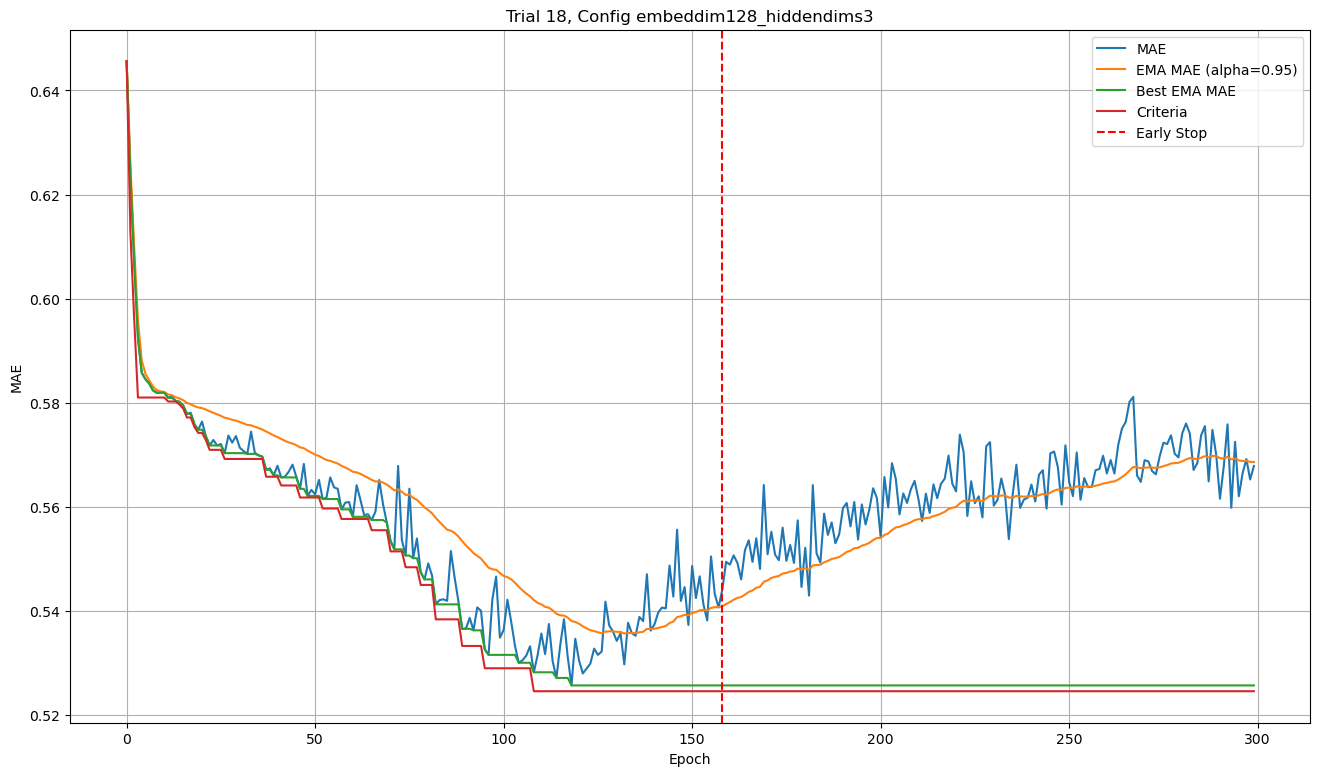

In [60]:
trial = 18
plot_mae_vs_ema(df_ema, df_stop, trial=trial, config="embeddim128_hiddendims3")
# plot_ema_var(df_ema, trial=trial, config="embeddim128_hiddendims2")

In [61]:
def plot_neff(df, trial, config):
    sub = df[(df["trial"] == trial) & (df["config"] == config)]
    sub = sub.sort_values("epoch")

    plt.figure(figsize=(12, 6))
    plt.plot(sub["epoch"], sub["n_eff"], label="Effective Sample Size", linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("Effective Sample Size (n_eff)")
    plt.title(f"Effective Sample Size Over Epochs - Trial {trial}, Config {config}")
    plt.legend()
    plt.grid(True)
    plt.show()

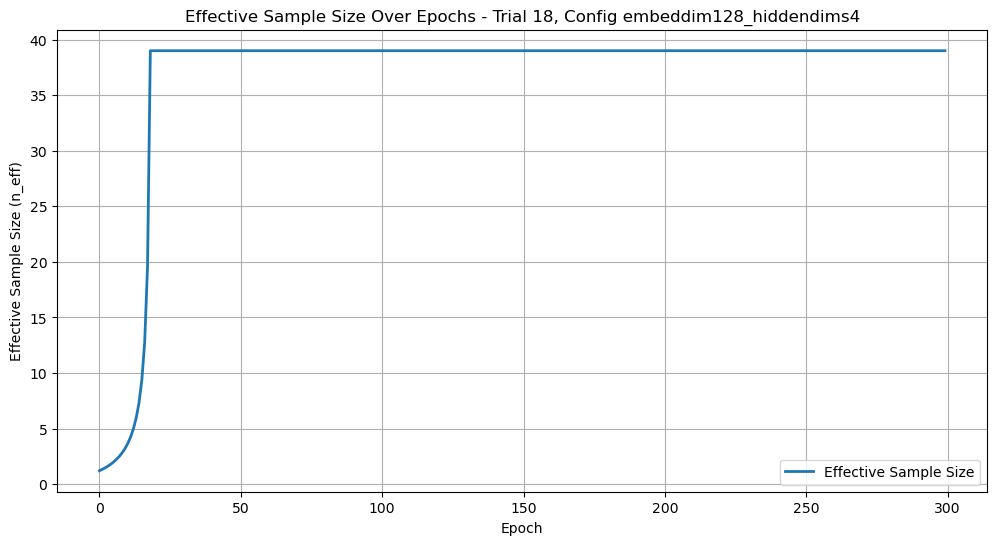

In [62]:
plot_neff(df_ema, trial=trial, config="embeddim128_hiddendims4")